<a href="https://colab.research.google.com/github/samihannn/aml-exps-samihan/blob/main/AML_Exp_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Original Dataset ---
Day  Outlook Temp Humidity   Wind Play Tennis
 D1    Sunny  Hot     High   Weak          No
 D2    Sunny  Hot     High Strong          No
 D3 Overcast  Hot     High   Weak         Yes
 D4     Rain Mild     High   Weak         Yes
 D5     Rain Cool   Normal   Weak         Yes
 D6     Rain Cool   Normal Strong          No
 D7 Overcast Cool   Normal Strong         Yes
 D8    Sunny Mild     High   Weak          No
 D9    Sunny Cool   Normal   Weak         Yes
D10     Rain Mild   Normal   Weak         Yes
D11    Sunny Mild   Normal Strong         Yes
D12 Overcast Mild     High Strong         Yes
D13 Overcast  Hot   Normal   Weak         Yes
D14     Rain Mild     High Strong          No


--- Model Performance ---
Accuracy:  0.60
Precision: 0.67
Recall:    0.67
F1-Score:  0.67

--- Detailed Classification Report ---
              precision    recall  f1-score   support

      No (0)       0.50      0.50      0.50         2
     Yes (1)       0.67      0.67      0.67 

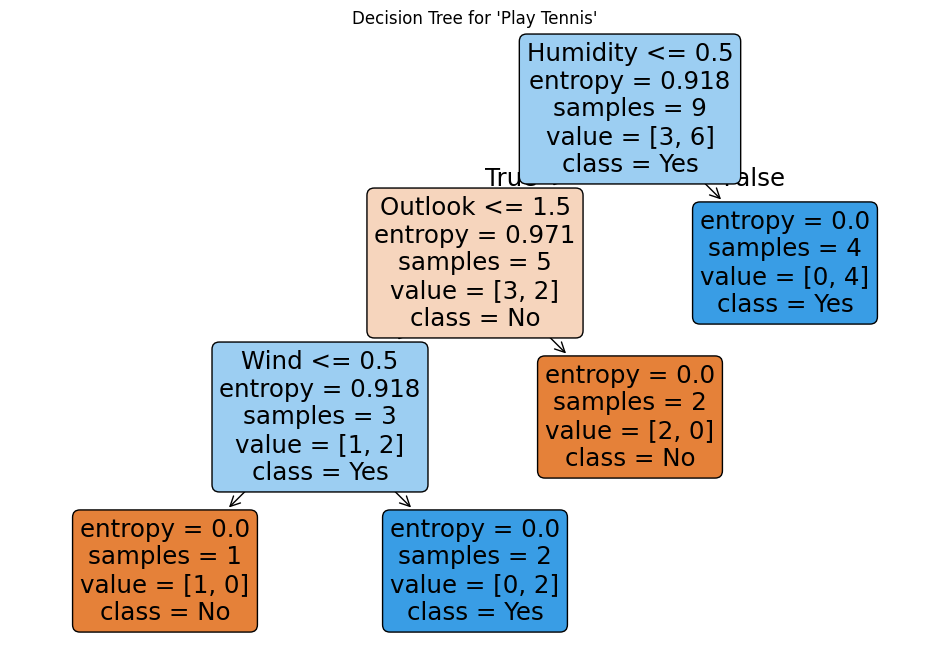

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt


data = {
    'Day': ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14'],
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temp': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'Play Tennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)
print("--- Original Dataset ---")
print(df.to_string(index=False))
print("\n" + "="*50 + "\n")

df_encoded = df.copy()
for col in ['Outlook', 'Temp', 'Humidity', 'Wind']:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes


df_encoded['Play Tennis'] = df_encoded['Play Tennis'].map({'No': 0, 'Yes': 1})


X = df_encoded[['Outlook', 'Temp', 'Humidity', 'Wind']]
y = df_encoded['Play Tennis']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("--- Model Performance ---")
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-Score:  {f1:.2f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))
print("="*50 + "\n")


plt.figure(figsize=(12, 8))
plot_tree(clf,
          feature_names=['Outlook', 'Temp', 'Humidity', 'Wind'],
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True)
plt.title("Decision Tree for 'Play Tennis'")
plt.show()